In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

In [2]:
# Paramètres
n_timesteps = 50
beta_t = np.linspace(0.0001, 0.02, n_timesteps).astype(np.float32)
alpha_t = 1- beta_t
alpha_bar_t = np.cumprod(alpha_t)
beta_bar_t = 1 - alpha_bar_t

# Génération des données d'entraînement
print("Génération des données...")
x = np.random.uniform(-2, 2, 50000)
y = np.sin(2*np.pi*x)
real_data = np.stack([x, y], axis=1)

# Préparation du dataset d'entraînement
X_noisy, X_timesteps, y_noise = [], [], []

for i in range(len(real_data)):
    t = np.random.randint(0, n_timesteps)
    noise = np.random.randn(1,2)
    noisy = np.sqrt(alpha_bar_t[t])*real_data[i:i+1]+np.sqrt(1-alpha_bar_t[t])*noise
    
    X_noisy.append(noisy)
    X_timesteps.append([t / n_timesteps])  # Normalisation du timestep
    y_noise.append(noise)

X_noisy = np.array(X_noisy).reshape((50000,2))
X_timesteps = np.array(X_timesteps)
y_noise = np.array(y_noise).reshape((50000,2))

Génération des données...


In [3]:
# Création et entraînement du modèle
print("Création du modèle...")

data_input = layers.Input(shape=(2,), name='data')
t_input = layers.Input(shape=(1,), name='timestep')

# Embedding du timestep
t_emb = layers.Dense(32, activation='relu')(t_input)

# Fusion des inputs
x = layers.Concatenate()([data_input, t_emb])

# Réseau simple
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)

# Prédiction du bruit
noise_pred = layers.Dense(2)(x)
    
model = keras.Model(inputs=[data_input, t_input], outputs=noise_pred)

model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse')

Création du modèle...


In [4]:
print("Entraînement du modèle...")
model.fit([X_noisy, X_timesteps],y_noise,epochs=30,batch_size=512,validation_split=0.1,verbose=1)

Entraînement du modèle...
Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8294 - val_loss: 0.7955
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7662 - val_loss: 0.7659
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7465 - val_loss: 0.7510
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7368 - val_loss: 0.7437
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7302 - val_loss: 0.7524
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7266 - val_loss: 0.7370
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7204 - val_loss: 0.7322
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7161 - val_loss: 0.7308
Epoch 9/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7122 - val_loss: 0.7243
Epoch 10/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7081 - val_loss: 0.7235
Epoch 11/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7047 - val_loss: 0.7185
Epoch 12/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/st


Génération de nouveaux échantillons...


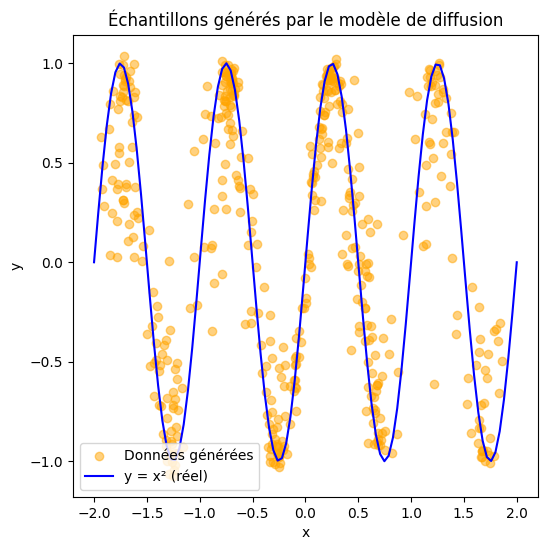

In [5]:
print("\nGénération de nouveaux échantillons...")
n_samples = 500
# Étape 1 : on part d'un bruit gaussien
x_gen = np.random.randn(n_samples, 2)

# Étape 2 : débruitage progressif
for t in reversed(range(n_timesteps)):
    t_tensor = np.full((n_samples, 1), t / n_timesteps)
    pred_noise = model.predict([x_gen, t_tensor], verbose=0)

    alpha_bar = alpha_bar_t[t]
    if t > 0:
        alpha_bar_prev = alpha_bar_t[t-1]
    else:
        alpha_bar_prev = 1.0  

    beta_bar_t = 1 - alpha_bar
    beta_bar_prev = 1 - alpha_bar_prev

    x0_pred = (x_gen - np.sqrt(beta_bar_t) * pred_noise) / np.sqrt(alpha_bar)

    noise = np.random.randn(n_samples, 2)

    x_gen = np.sqrt(alpha_bar_prev) * x0_pred + np.sqrt(beta_bar_prev) * noise

# Étape 3 : on représente les points générés par le modèle de diffusion
#           et on compare avec la courbe d'équation y = x^2
plt.figure(figsize=(6, 6))
plt.scatter(x_gen[:, 0], x_gen[:, 1], color='orange', alpha=0.5, label='Données générées')
x_ref = np.linspace(-2, 2, 100)
plt.plot(x_ref, np.sin(2*np.pi*x_ref), color='blue', label='y = x² (réel)')
plt.legend()
plt.title("Échantillons générés par le modèle de diffusion")
plt.xlabel("x")
plt.ylabel("y")
plt.show()